In [137]:
import pandas as pd

df = pd.read_csv("Student Social Media And Mental Health Impact.csv")

df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [138]:
#Basic details of dataset
print("Dataset shape:", df.shape)



Dataset shape: (5000, 13)


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [140]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [141]:
#column names
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [142]:
# check the missing values
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [143]:
# check the duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 2


In [144]:
# check the target column
df["Stress_Level"].value_counts()

,count
Stress_Level,
Very High,1621
High,1440
Medium,1295
Low,644


In [145]:
# Target column percentage
df["Stress_Level"].value_counts(normalize=True) * 100

,proportion
Stress_Level,
Very High,32.42
High,28.80
Medium,25.90
Low,12.88


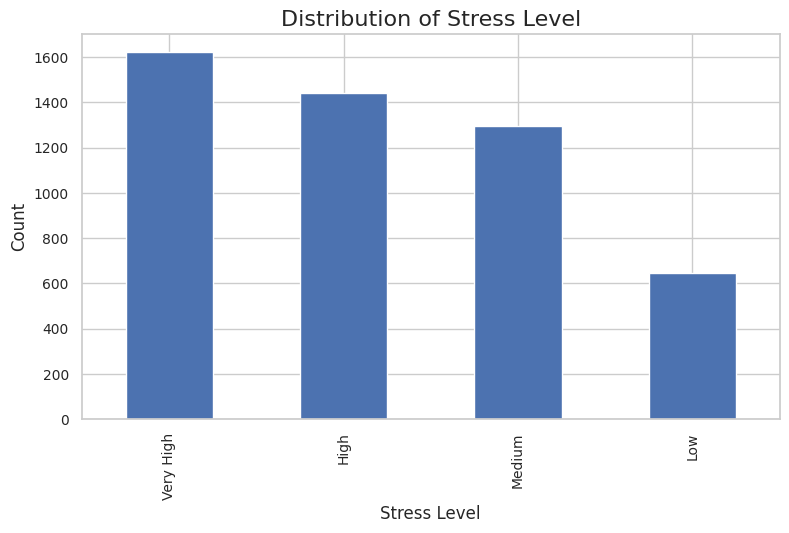

In [146]:
# Target distribution bar chart
import matplotlib.pyplot as plt

df["Stress_Level"].value_counts().plot(kind="bar")

plt.title("Distribution of Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Count")
plt.show()


In [147]:
# Data cleaning and preparation
data = df.copy()

In [148]:
# Clean the column names
data.columns = data.columns.str.strip()

print(data.columns)

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')


In [149]:
# Remove the Duplicate Rows
print("Before removing duplicates:", data.shape)

data = data.drop_duplicates()

print("After removing duplicates:", data.shape)

Before removing duplicates: (5000, 13)
After removing duplicates: (4998, 13)


In [150]:
# Check After the missing values
data.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [151]:
# Handle the missing values
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = data.select_dtypes(include=["object"]).columns

for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [152]:
# check the missing values have or not
data.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [153]:
# Set the Target column
target = "Stress_Level"

X = data.drop(target, axis=1)
y = data[target]

In [154]:
# Check the Features and Target
print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()
y.head()

Features shape: (4998, 12)
Target shape: (4998,)


,Stress_Level
0,Medium
1,Low
2,Medium
3,Very High
4,Very High


In [155]:
# Separate Numerical And categorical columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')

Categorical Features:
Index(['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use'],
      dtype='object')


In [156]:
# Exploratory data analysis
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

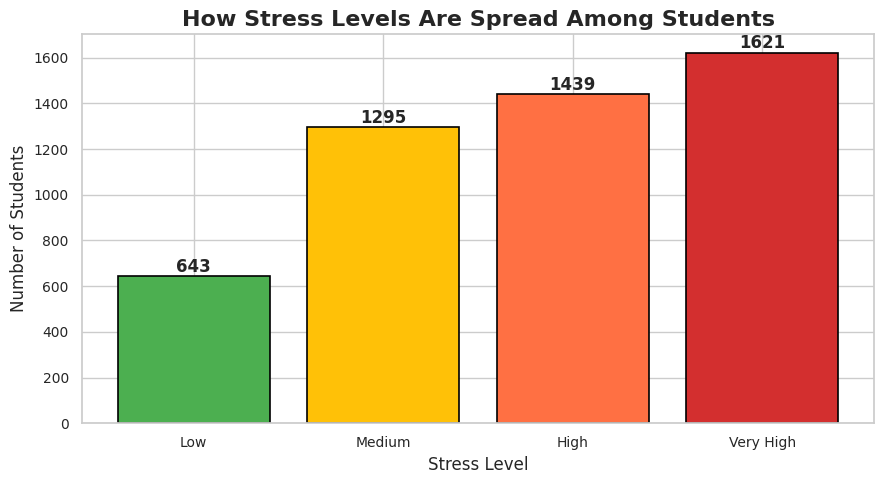

In [157]:
# Stress Level Distribution Chart
stress_order = ["Low", "Medium", "High", "Very High"]

stress_counts = data["Stress_Level"].value_counts().reindex(stress_order)

colors = ["#4CAF50", "#FFC107", "#FF7043", "#D32F2F"]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    stress_counts.index,
    stress_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

plt.title("How Stress Levels Are Spread Among Students", fontweight="bold")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        int(height),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

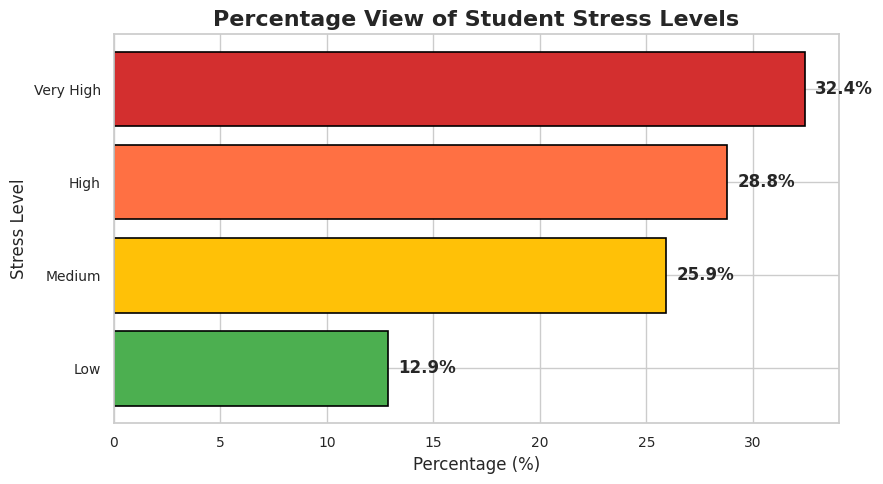

In [158]:
# Get the Percentage Chart
stress_percentages = data["Stress_Level"].value_counts(normalize=True).reindex(stress_order) * 100

plt.figure(figsize=(9, 5))

bars = plt.barh(
    stress_percentages.index,
    stress_percentages.values,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

plt.title("Percentage View of Student Stress Levels", fontweight="bold")
plt.xlabel("Percentage (%)")
plt.ylabel("Stress Level")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

/tmp/ipykernel_542/2011176957.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


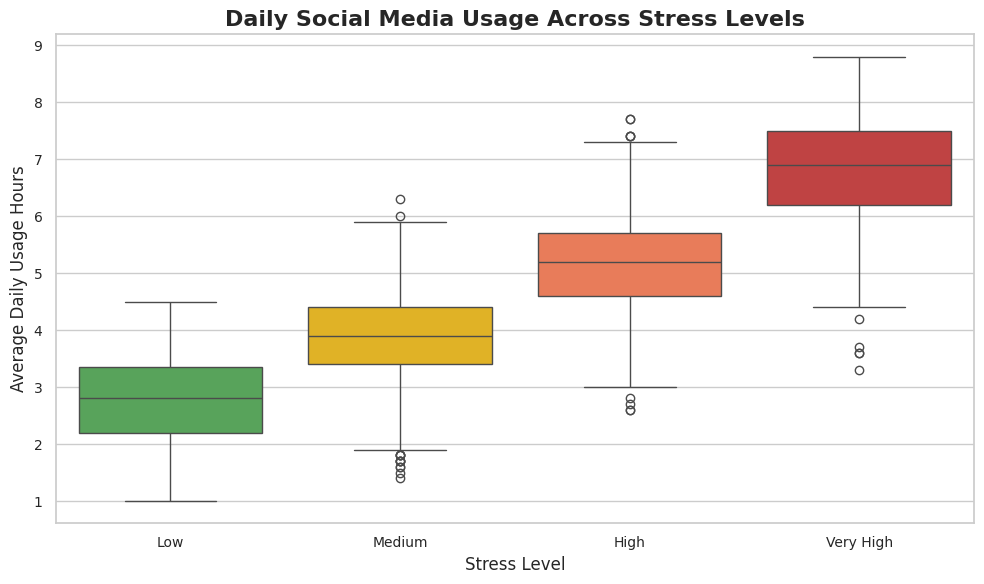

In [159]:
# Average Daily usage Hours vs Stress Level
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="Stress_Level",
    y="Avg_Daily_Usage_Hours",
    order=["Low", "Medium", "High", "Very High"],
    palette=["#4CAF50", "#FFC107", "#FF7043", "#D32F2F"]
)

plt.title("Daily Social Media Usage Across Stress Levels", fontweight="bold")
plt.xlabel("Stress Level")
plt.ylabel("Average Daily Usage Hours")

plt.tight_layout()
plt.show()

/tmp/ipykernel_542/167531823.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


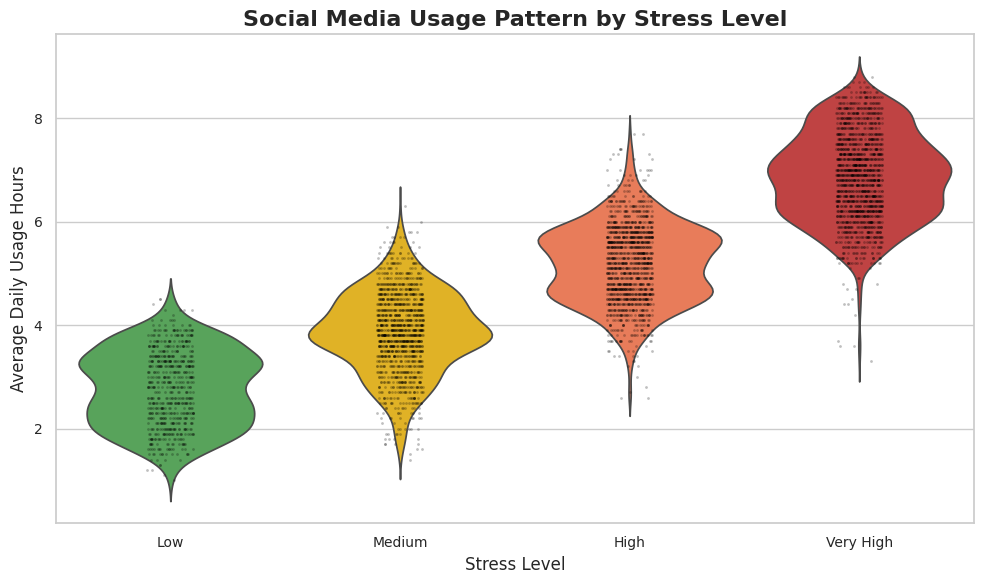

In [160]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=data,
    x="Stress_Level",
    y="Avg_Daily_Usage_Hours",
    order=["Low", "Medium", "High", "Very High"],
    palette=["#4CAF50", "#FFC107", "#FF7043", "#D32F2F"],
    inner=None
)

sns.stripplot(
    data=data,
    x="Stress_Level",
    y="Avg_Daily_Usage_Hours",
    order=["Low", "Medium", "High", "Very High"],
    color="black",
    alpha=0.25,
    jitter=True,
    size=2
)

plt.title("Social Media Usage Pattern by Stress Level", fontweight="bold")
plt.xlabel("Stress Level")
plt.ylabel("Average Daily Usage Hours")

plt.tight_layout()
plt.show()

/tmp/ipykernel_542/3388850163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


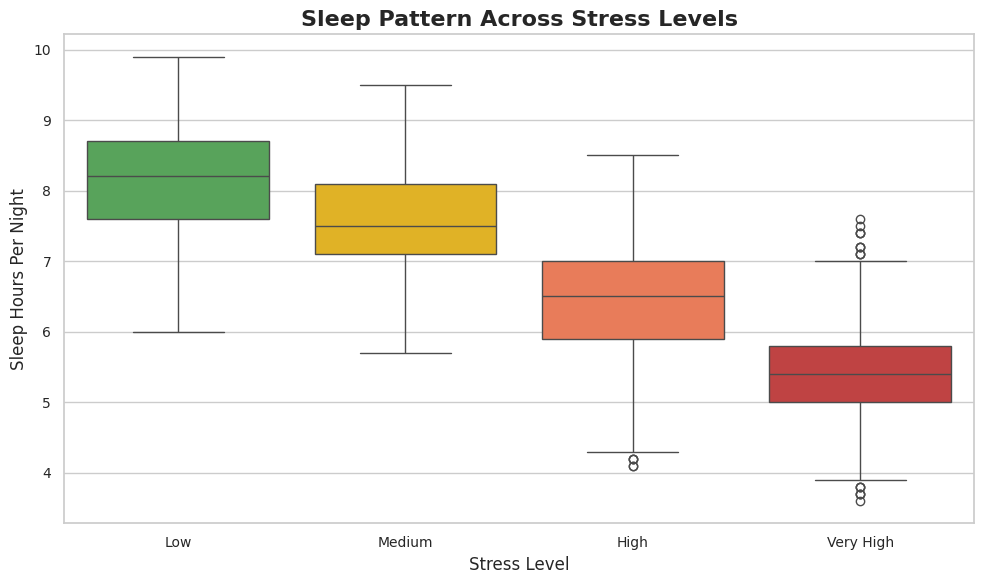

In [161]:
# sleep Hours vs Stress Level
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="Stress_Level",
    y="Sleep_Hours_Per_Night",
    order=["Low", "Medium", "High", "Very High"],
    palette=["#4CAF50", "#FFC107", "#FF7043", "#D32F2F"]
)

plt.title("Sleep Pattern Across Stress Levels", fontweight="bold")
plt.xlabel("Stress Level")
plt.ylabel("Sleep Hours Per Night")

plt.tight_layout()
plt.show()

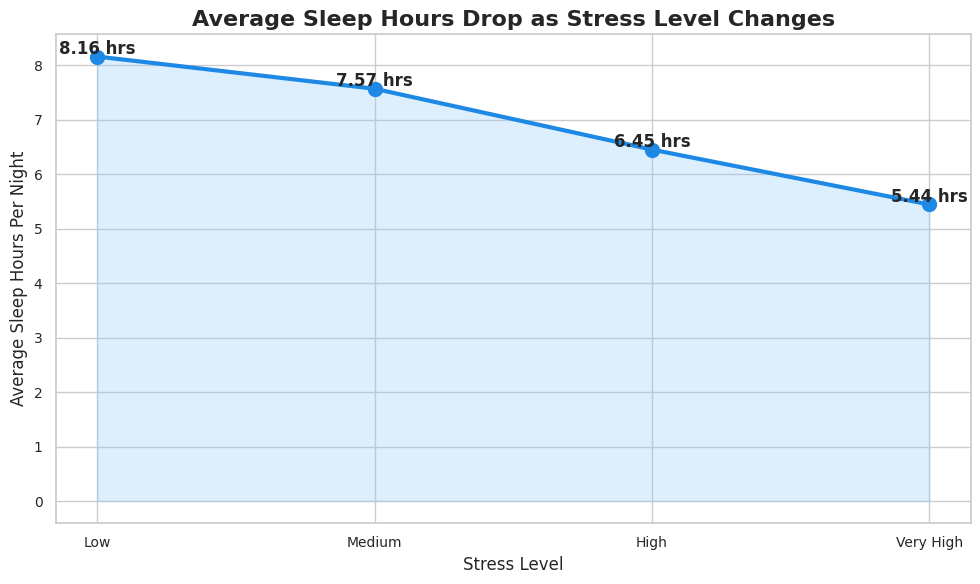

In [162]:
# Sleep trend with mean points
sleep_mean = data.groupby("Stress_Level")["Sleep_Hours_Per_Night"].mean().reindex(
    ["Low", "Medium", "High", "Very High"]
)

plt.figure(figsize=(10, 6))

plt.plot(
    sleep_mean.index,
    sleep_mean.values,
    marker="o",
    linewidth=3,
    markersize=10,
    color="#1E88E5"
)

plt.fill_between(
    sleep_mean.index,
    sleep_mean.values,
    color="#90CAF9",
    alpha=0.3
)

for i, value in enumerate(sleep_mean.values):
    plt.text(
        i,
        value + 0.05,
        f"{value:.2f} hrs",
        ha="center",
        fontweight="bold"
    )

plt.title("Average Sleep Hours Drop as Stress Level Changes", fontweight="bold")
plt.xlabel("Stress Level")
plt.ylabel("Average Sleep Hours Per Night")

plt.tight_layout()
plt.show()

/tmp/ipykernel_542/590450236.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


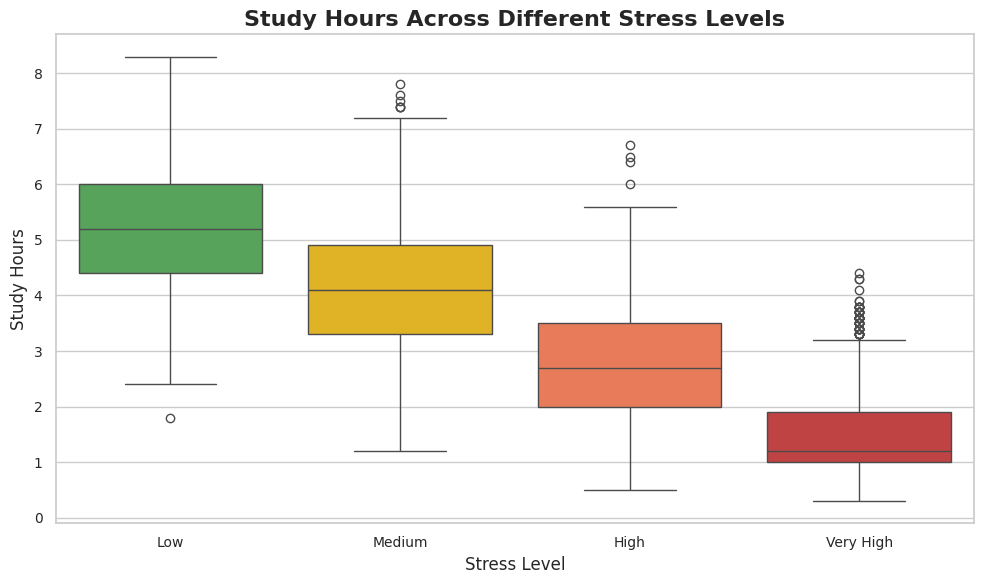

In [163]:
# Study hours vs Stress level
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="Stress_Level",
    y="Study_Hours",
    order=["Low", "Medium", "High", "Very High"],
    palette=["#4CAF50", "#FFC107", "#FF7043", "#D32F2F"]
)

plt.title("Study Hours Across Different Stress Levels", fontweight="bold")
plt.xlabel("Stress Level")
plt.ylabel("Study Hours")

plt.tight_layout()
plt.show()

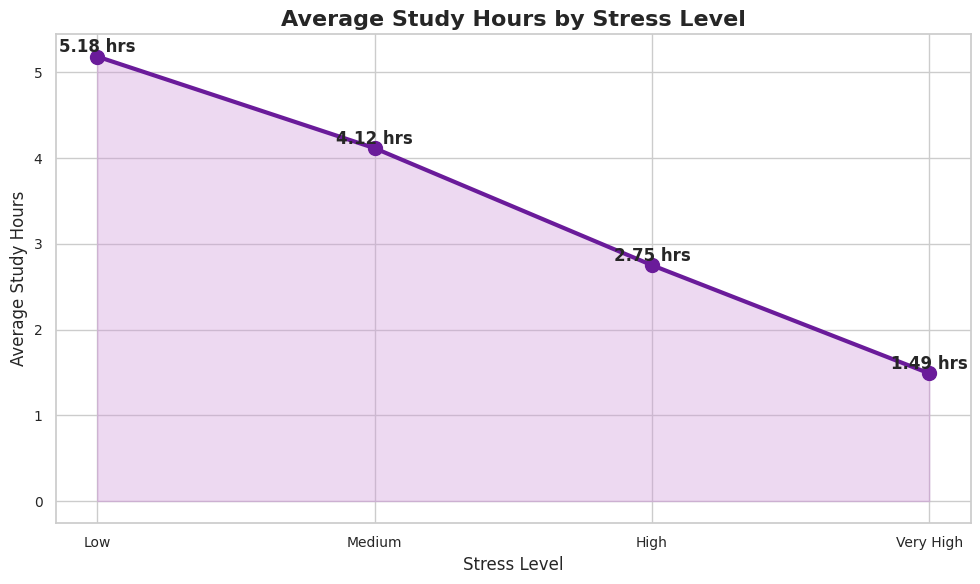

In [164]:
# Average study hours trend
study_mean = data.groupby("Stress_Level")["Study_Hours"].mean().reindex(
    ["Low", "Medium", "High", "Very High"]
)

plt.figure(figsize=(10, 6))

plt.plot(
    study_mean.index,
    study_mean.values,
    marker="o",
    linewidth=3,
    markersize=10,
    color="#6A1B9A"
)

plt.fill_between(
    study_mean.index,
    study_mean.values,
    color="#CE93D8",
    alpha=0.35
)

for i, value in enumerate(study_mean.values):
    plt.text(
        i,
        value + 0.05,
        f"{value:.2f} hrs",
        ha="center",
        fontweight="bold"
    )

plt.title("Average Study Hours by Stress Level", fontweight="bold")
plt.xlabel("Stress Level")
plt.ylabel("Average Study Hours")

plt.tight_layout()
plt.show()

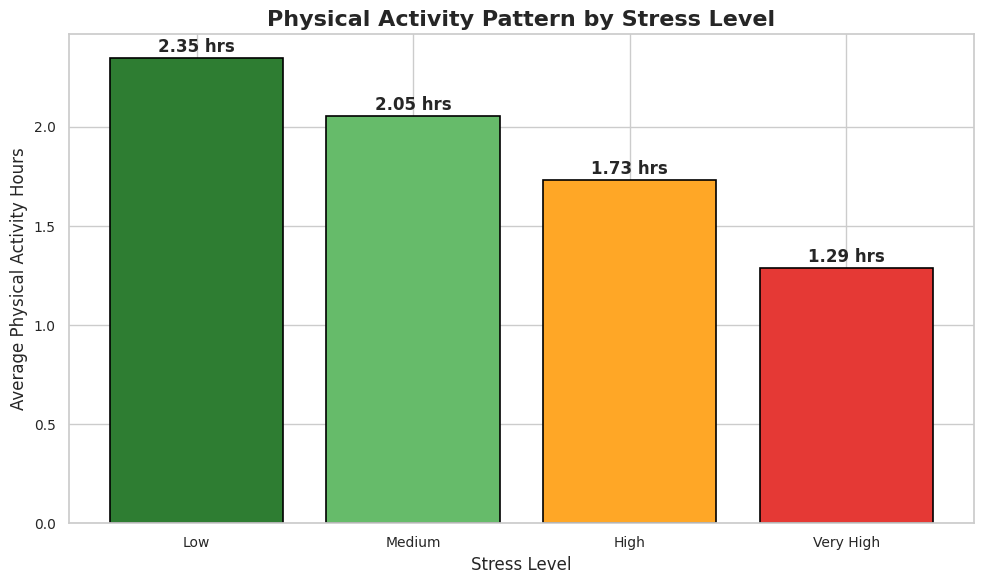

In [165]:
# Physical Activity vs Stress Level
activity_mean = data.groupby("Stress_Level")["Physical_Activity_Hours"].mean().reindex(
    ["Low", "Medium", "High", "Very High"]
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    activity_mean.index,
    activity_mean.values,
    color=["#2E7D32", "#66BB6A", "#FFA726", "#E53935"],
    edgecolor="black",
    linewidth=1.2
)

plt.title("Physical Activity Pattern by Stress Level", fontweight="bold")
plt.xlabel("Stress Level")
plt.ylabel("Average Physical Activity Hours")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.03,
        f"{height:.2f} hrs",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

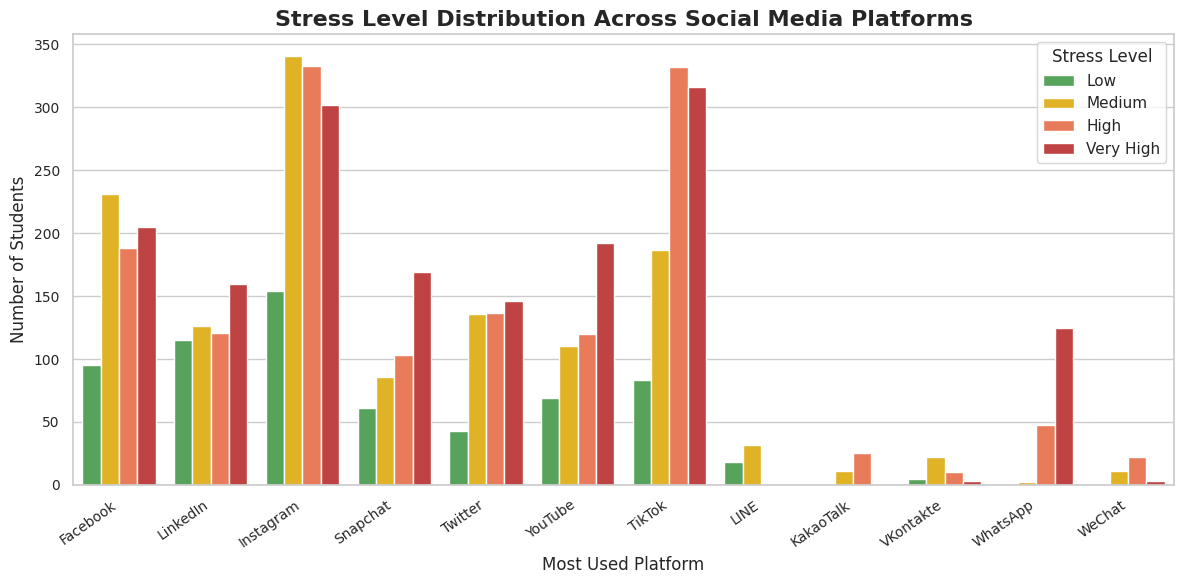

In [166]:
# Platform vs Stress Level count
plt.figure(figsize=(12, 6))

sns.countplot(
    data=data,
    x="Most_Used_Platform",
    hue="Stress_Level",
    hue_order=["Low", "Medium", "High", "Very High"],
    palette=["#4CAF50", "#FFC107", "#FF7043", "#D32F2F"]
)

plt.title("Stress Level Distribution Across Social Media Platforms", fontweight="bold")
plt.xlabel("Most Used Platform")
plt.ylabel("Number of Students")

plt.xticks(rotation=35, ha="right")
plt.legend(title="Stress Level")

plt.tight_layout()
plt.show()

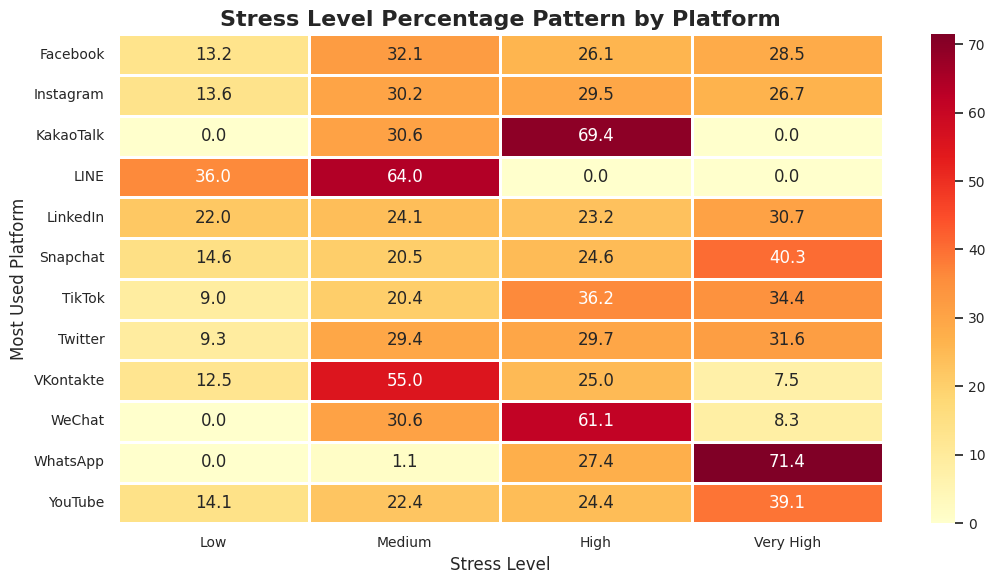

In [167]:
# Heat map
platform_stress = pd.crosstab(
    data["Most_Used_Platform"],
    data["Stress_Level"],
    normalize="index"
) * 100

platform_stress = platform_stress[["Low", "Medium", "High", "Very High"]]

plt.figure(figsize=(11, 6))

sns.heatmap(
    platform_stress,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.8,
    linecolor="white"
)

plt.title("Stress Level Percentage Pattern by Platform", fontweight="bold")
plt.xlabel("Stress Level")
plt.ylabel("Most Used Platform")

plt.tight_layout()
plt.show()

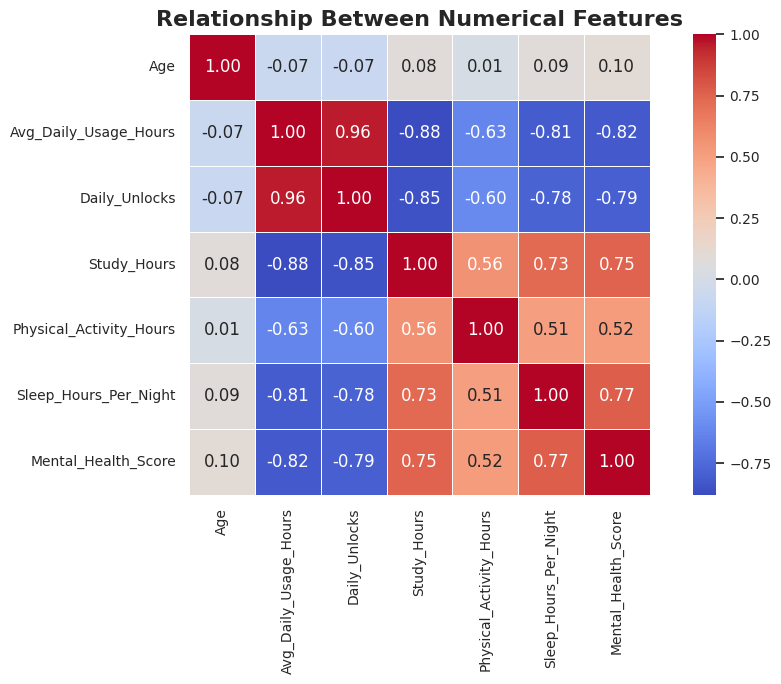

In [168]:
# Correlation Heatmap for Numerical Features
numeric_data = data.select_dtypes(include=["int64", "float64"])

corr_matrix = numeric_data.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.7,
    linecolor="white",
    square=True
)

plt.title("Relationship Between Numerical Features", fontweight="bold")
plt.tight_layout()
plt.show()


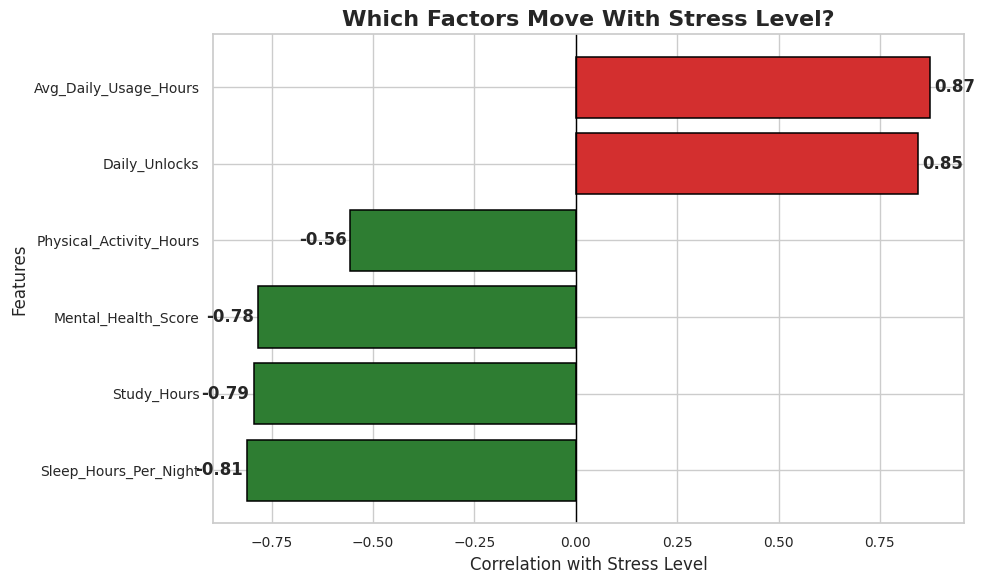

In [169]:
# Relation with stress level
stress_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "Very High": 3
}

data_corr = data.copy()
data_corr["Stress_Level_Encoded"] = data_corr["Stress_Level"].map(stress_mapping)

selected_cols = [
    "Avg_Daily_Usage_Hours",
    "Daily_Unlocks",
    "Study_Hours",
    "Physical_Activity_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score",
    "Stress_Level_Encoded"
]

stress_corr = data_corr[selected_cols].corr()["Stress_Level_Encoded"].drop("Stress_Level_Encoded")
stress_corr = stress_corr.sort_values()

plt.figure(figsize=(10, 6))

colors = ["#2E7D32" if value < 0 else "#D32F2F" for value in stress_corr.values]

bars = plt.barh(
    stress_corr.index,
    stress_corr.values,
    color=colors,
    edgecolor="black",
    linewidth=1.1
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Which Factors Move With Stress Level?", fontweight="bold")
plt.xlabel("Correlation with Stress Level")
plt.ylabel("Features")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01 if width >= 0 else width - 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        ha="left" if width >= 0 else "right",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [170]:
# ecoding-train,test split
target = "Stress_Level"

X = data.drop(target, axis=1)
y = data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4998, 12)
y shape: (4998,)


In [171]:
# Target column of label encode
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded target sample:", y_encoded[:10])

Classes: ['High' 'Low' 'Medium' 'Very High']
Encoded target sample: [2 1 2 3 3 1 3 0 0 2]


In [172]:
# Encode for categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

print("Before encoding:", X.shape)
print("After encoding:", X_encoded.shape)



Before encoding: (4998, 12)
After encoding: (4998, 134)


In [173]:
# train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3998, 134)
X_test shape: (1000, 134)
y_train shape: (3998,)
y_test shape: (1000,)


In [174]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [175]:
# import models and metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [176]:
# train KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_predictions = knn_model.predict(X_test_scaled)

In [177]:
# Evaluate KNN model
knn_accuracy = accuracy_score(y_test, knn_predictions)

print("KNN Accuracy:", knn_accuracy)
print("\nKNN Classification Report:")
print(classification_report(y_test, knn_predictions, target_names=label_encoder.classes_))

KNN Accuracy: 0.759

KNN Classification Report:
              precision    recall  f1-score   support

        High       0.69      0.75      0.72       288
         Low       0.76      0.67      0.71       129
      Medium       0.69      0.68      0.68       259
   Very High       0.88      0.87      0.87       324

    accuracy                           0.76      1000
   macro avg       0.75      0.74      0.75      1000
weighted avg       0.76      0.76      0.76      1000



In [178]:
# Train Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_predictions = log_model.predict(X_test_scaled)

In [179]:
# Evaluate Logistic Regression model
log_accuracy = accuracy_score(y_test, log_predictions)

print("Logistic Regression Accuracy:", log_accuracy)
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, log_predictions, target_names=label_encoder.classes_))

Logistic Regression Accuracy: 0.751

Logistic Regression Classification Report:
              precision    recall  f1-score   support

        High       0.68      0.71      0.70       288
         Low       0.74      0.67      0.71       129
      Medium       0.67      0.67      0.67       259
   Very High       0.88      0.89      0.88       324

    accuracy                           0.75      1000
   macro avg       0.74      0.73      0.74      1000
weighted avg       0.75      0.75      0.75      1000



In [180]:
# Train SVM model
svm_model = SVC(kernel="rbf", random_state=42)

svm_model.fit(X_train_scaled, y_train)

svm_predictions = svm_model.predict(X_test_scaled)

In [181]:
# Evaluate SVM model
svm_accuracy = accuracy_score(y_test, svm_predictions)

print("SVM Accuracy:", svm_accuracy)
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_predictions, target_names=label_encoder.classes_))

SVM Accuracy: 0.745

SVM Classification Report:
              precision    recall  f1-score   support

        High       0.69      0.68      0.68       288
         Low       0.76      0.61      0.68       129
      Medium       0.66      0.68      0.67       259
   Very High       0.86      0.91      0.88       324

    accuracy                           0.74      1000
   macro avg       0.74      0.72      0.73      1000
weighted avg       0.74      0.74      0.74      1000



In [182]:
# Compare All three models
model_results = pd.DataFrame({
    "Model": ["KNN", "Logistic Regression", "SVM"],
    "Accuracy": [knn_accuracy, log_accuracy, svm_accuracy]
})

model_results

,Model,Accuracy
0,KNN,0.759
1,Logistic Regression,0.751
2,SVM,0.745


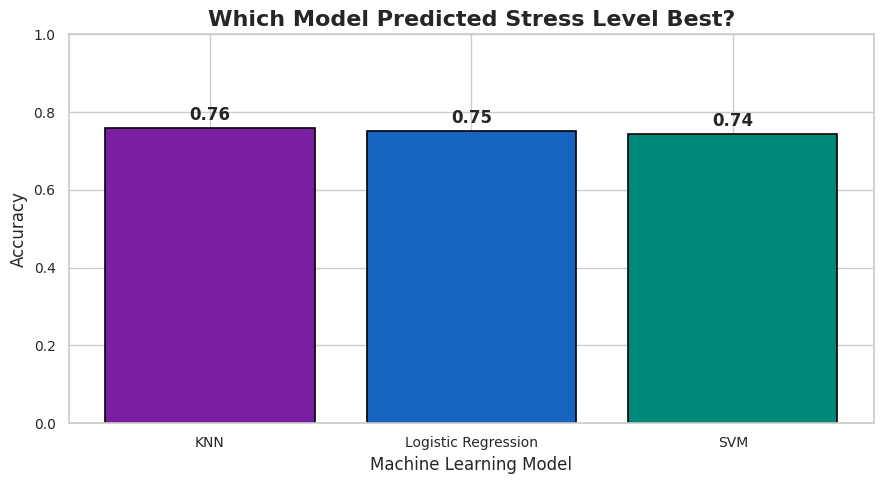

In [183]:
# Model comparison chart
plt.figure(figsize=(9, 5))

colors = ["#7B1FA2", "#1565C0", "#00897B"]

bars = plt.bar(
    model_results["Model"],
    model_results["Accuracy"],
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

plt.title("Which Model Predicted Stress Level Best?", fontweight="bold")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [184]:
# plot the confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        linewidths=0.7,
        linecolor="white"
    )

    plt.title(f"Confusion Matrix - {model_name}", fontweight="bold")
    plt.xlabel("Predicted Stress Level")
    plt.ylabel("Actual Stress Level")

    plt.tight_layout()
    plt.show()

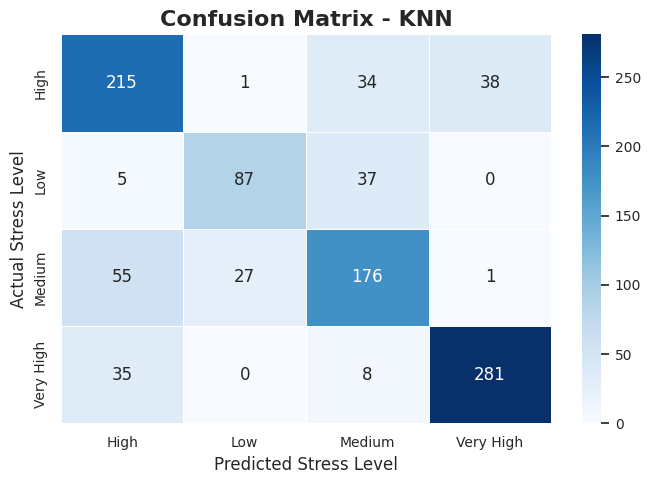

In [185]:
# KNN confusion matrix
plot_confusion_matrix(y_test, knn_predictions, "KNN")

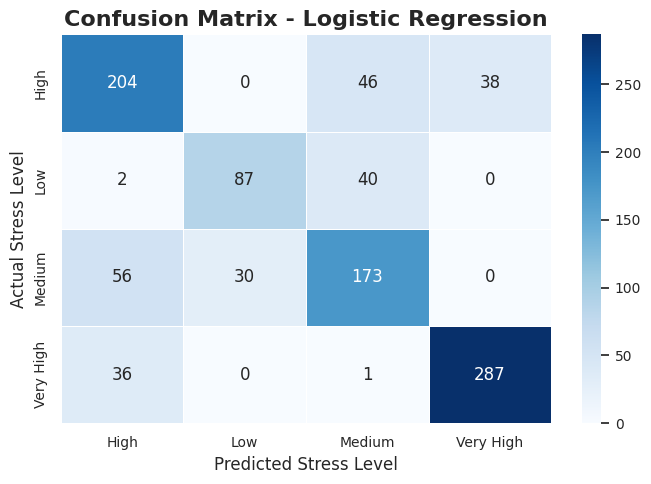

In [186]:
# Logistic regression confusion matrix
plot_confusion_matrix(y_test, log_predictions, "Logistic Regression")

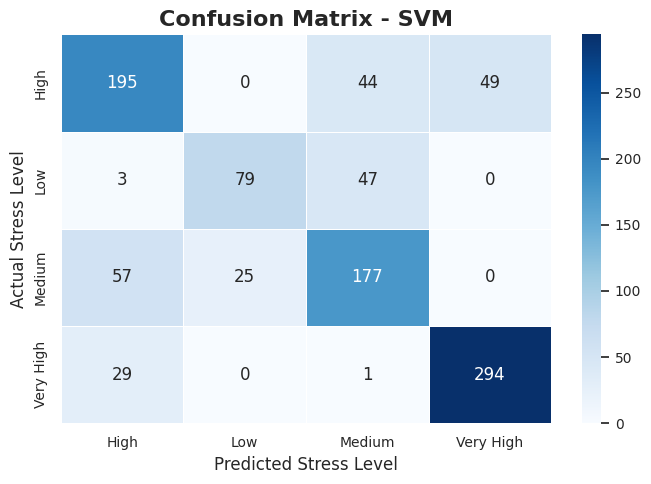

In [187]:
# SVM confusion matrix
plot_confusion_matrix(y_test, svm_predictions, "SVM")

In [188]:
# select the best model
best_model_row = model_results.loc[model_results["Accuracy"].idxmax()]

best_model_name = best_model_row["Model"]
best_model_accuracy = best_model_row["Accuracy"]

print("Best Model:", best_model_name)
print("Best Accuracy:", best_model_accuracy)

Best Model: KNN
Best Accuracy: 0.759


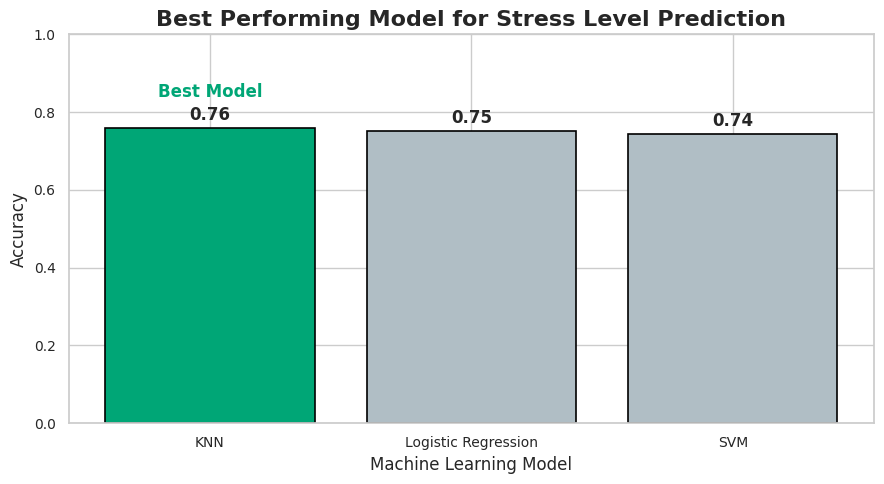

In [189]:
# best model for highlight
highlight_colors = []

for model in model_results["Model"]:
    if model == best_model_name:
        highlight_colors.append("#00A676")   # green for best model
    else:
        highlight_colors.append("#B0BEC5")   # grey for other models

plt.figure(figsize=(9, 5))

bars = plt.bar(
    model_results["Model"],
    model_results["Accuracy"],
    color=highlight_colors,
    edgecolor="black",
    linewidth=1.2
)

plt.title("Best Performing Model for Stress Level Prediction", fontweight="bold")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.text(
    model_results[model_results["Model"] == best_model_name].index[0],
    best_model_accuracy + 0.08,
    "Best Model",
    ha="center",
    fontweight="bold",
    color="#00A676"
)

plt.tight_layout()
plt.show()


In [190]:
# create prediction setup
if best_model_name == "KNN":
    best_model = knn_model
    best_predictions = knn_predictions
    use_scaled_data = True

elif best_model_name == "Logistic Regression":
    best_model = log_model
    best_predictions = log_predictions
    use_scaled_data = True

else:
    best_model = svm_model
    best_predictions = svm_predictions
    use_scaled_data = True

print("Selected Best Model:", best_model_name)

Selected Best Model: KNN


In [191]:
# Evaluation summary table
final_results = model_results.sort_values(by="Accuracy", ascending=False)

final_results

,Model,Accuracy
0,KNN,0.759
1,Logistic Regression,0.751
2,SVM,0.745


In [192]:
# Actual vs predicted values table
prediction_results = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(best_predictions)
})

prediction_results.head(20)

,Actual,Predicted
0,Medium,Medium
1,High,Very High
2,Low,High
3,Medium,High
4,Medium,High
5,Very High,Very High
6,Medium,Low
7,Very High,Very High
8,Medium,Medium
9,High,High


In [193]:
# Best model accuracy
final_accuracy = accuracy_score(y_test, best_predictions)

print("Final Selected Model:", best_model_name)
print("Final Accuracy:", final_accuracy)

Final Selected Model: KNN
Final Accuracy: 0.759


In [194]:
print("Machine Learning Classification Completed")
print("----------------------------------------")
print("Target Variable: Stress_Level")
print("Models Used: KNN, Logistic Regression, SVM")
print("Best Model:", best_model_name)
print("Best Accuracy:", round(final_accuracy, 4))

Machine Learning Classification Completed
----------------------------------------
Target Variable: Stress_Level
Models Used: KNN, Logistic Regression, SVM
Best Model: KNN
Best Accuracy: 0.759


In [195]:
# predict stress level for a new student
X.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')

In [196]:
# create a new student input
new_student = pd.DataFrame({
    "Age": [21],
    "Gender": ["Male"],
    "Country": ["Sri Lanka"],
    "Academic_Level": ["Undergraduate"],
    "Most_Used_Platform": ["Instagram"],
    "Purpose_Of_Use": ["Entertainment"],
    "Avg_Daily_Usage_Hours": [5.5],
    "Daily_Unlocks": [180],
    "Study_Hours": [2.5],
    "Physical_Activity_Hours": [1.2],
    "Sleep_Hours_Per_Night": [6.0],
    "Mental_Health_Score": [6.0]
})

new_student


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,Male,Sri Lanka,Undergraduate,Instagram,Entertainment,5.5,180,2.5,1.2,6.0,6.0


In [197]:
# create new student input
new_student_encoded = pd.get_dummies(new_student)

new_student_encoded = new_student_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

new_student_encoded.head()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Gender_Male,Country_Albania,Country_Andorra,...,Most_Used_Platform_Snapchat,Most_Used_Platform_TikTok,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Purpose_Of_Use_Entertainment,Purpose_Of_Use_Networking,Purpose_Of_Use_News
0,21,5.5,180,2.5,1.2,6.0,6.0,True,0,0,...,0,0,0,0,0,0,0,True,0,0


In [198]:
# scale the new data
new_student_scaled = scaler.transform(new_student_encoded)


In [199]:
# prediction for best model
new_prediction = best_model.predict(new_student_scaled)

predicted_stress_level = label_encoder.inverse_transform(new_prediction)

print("Predicted Stress Level:", predicted_stress_level[0])


Predicted Stress Level: High


In [200]:
# prediction output
print("New Student Stress Level Prediction")
print("-----------------------------------")
print("Age:", new_student["Age"][0])
print("Most Used Platform:", new_student["Most_Used_Platform"][0])
print("Average Daily Usage Hours:", new_student["Avg_Daily_Usage_Hours"][0])
print("Daily Unlocks:", new_student["Daily_Unlocks"][0])
print("Study Hours:", new_student["Study_Hours"][0])
print("Sleep Hours Per Night:", new_student["Sleep_Hours_Per_Night"][0])
print("Mental Health Score:", new_student["Mental_Health_Score"][0])
print("-----------------------------------")
print("Predicted Stress Level:", predicted_stress_level[0])

New Student Stress Level Prediction
-----------------------------------
Age: 21
Most Used Platform: Instagram
Average Daily Usage Hours: 5.5
Daily Unlocks: 180
Study Hours: 2.5
Sleep Hours Per Night: 6.0
Mental Health Score: 6.0
-----------------------------------
Predicted Stress Level: High
